### ***1. Objetivos***

Este cuaderno construye un dataset a nivel de frontera (huecos entre frases consecutivas), lo guarda en `data/processed/boundaries/` y establece baselines triviales para la detección de cambio de autor.

### ***Imports y otros***

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 3)
plt.style.use("seaborn-v0_8")


def find_root() -> Path:
    current = Path.cwd()
    fallback = None
    for cand in [current, *current.parents]:
        has_raw = (cand / "data" / "raw").exists()
        has_processed = (cand / "data" / "processed").exists()
        if has_raw:
            return cand
        if has_processed and fallback is None:
            fallback = cand
    if fallback is not None:
        return fallback
    raise FileNotFoundError("No encuentro data/raw ni data/processed desde el cwd actual.")


BASE_DIR = find_root()
DATA_PROCESSED_DIR = BASE_DIR / "data" / "processed"
BOUNDARIES_DIR = DATA_PROCESSED_DIR / "boundaries"
BOUNDARIES_DIR.mkdir(parents=True, exist_ok=True)

LEVELS = ["easy", "medium", "hard"]
SPLITS = ["train", "validation"]
RNG = np.random.default_rng(42)

print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_PROCESSED_DIR: {DATA_PROCESSED_DIR}")
print(f"BOUNDARIES_DIR: {BOUNDARIES_DIR}")

BASE_DIR: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis
DATA_PROCESSED_DIR: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis/data/processed
BOUNDARIES_DIR: /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis/data/processed/boundaries


### ***2. Carga de frases procesadas***

In [2]:
def sentence_files_for_level(level: str):
    base_level = DATA_PROCESSED_DIR / level
    combined = base_level / "sentences.jsonl"
    files = []
    if combined.exists():
        files.append((combined, None))
    for split_dir in SPLITS:
        candidate = base_level / split_dir / "sentences.jsonl"
        if candidate.exists():
            files.append((candidate, split_dir))
    return files


def load_sentences_split(split: str) -> pd.DataFrame:
    frames = []
    required_cols = ["doc_id", "sent_id", "level", "split", "text_norm", "n_tokens", "is_boundary"]
    for level in LEVELS:
        for fp, split_hint in sentence_files_for_level(level):
            df = pd.read_json(fp, lines=True)
            if df.empty:
                continue
            if "level" not in df.columns:
                df["level"] = level
            if "split" not in df.columns and split_hint is not None:
                df["split"] = split_hint
            mask = df["split"] == split
            if mask.any():
                frames.append(df.loc[mask].copy())
    if not frames:
        return pd.DataFrame(columns=required_cols + ["global_sent_idx"])
    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values(["level", "doc_id", "sent_id"]).reset_index(drop=True)
    df["global_sent_idx"] = np.arange(len(df))
    return df


sentences_train = load_sentences_split("train")
sentences_val = load_sentences_split("validation")

print(f"Frases train: {len(sentences_train):,}")
print(f"Frases validation: {len(sentences_val):,}")

Frases train: 171,602
Frases validation: 36,558


In [3]:
sentences_train.head()

,doc_id,sent_id,level,split,text_norm,n_tokens,is_boundary,global_sent_idx
0,problem-1,0,easy,train,there s also incidents of testosterone insensitive males that have either ambiguous genitals or are phenotypically f...,17,False,0
1,problem-1,1,easy,train,female is the human default body plan so a number of conditions exist that cause female looking males,18,False,1
2,problem-1,2,easy,train,what about people born appearing num female complete with the bits but are genetically males,15,False,2
3,problem-1,3,easy,train,who can they have sex with without sinning,8,False,3
4,problem-1,4,easy,train,according to the bible are they men or women,9,False,4


In [4]:
sentences_train['level'].value_counts()

level
medium    63386
hard      55515
easy      52701
Name: count, dtype: int64

In [5]:
sentences_train['n_tokens'].describe()

count    171602.000
mean         18.139
std          13.780
min           0.000
25%           9.000
50%          15.000
75%          25.000
max         500.000
Name: n_tokens, dtype: float64

In [6]:
sentences_val.head()

,doc_id,sent_id,level,split,text_norm,n_tokens,is_boundary,global_sent_idx
0,problem-1,0,easy,validation,you are on the fact that we need turkey s geography,11,False,0
1,problem-1,1,easy,validation,otherwise erdogan would have been gone long ago,8,True,1
2,problem-1,2,easy,validation,every war ship even it destroyer frigate corvette or other you name it is doing battle on water not on land human li...,159,True,2
3,problem-1,3,easy,validation,oh he would definitely try that,6,False,3
4,problem-1,4,easy,validation,and any other stupid tyrant throwing a temper tantrum dipshit thing he could think of,15,False,4


In [7]:
sentences_val['level'].value_counts()

level
medium    13763
hard      11649
easy      11146
Name: count, dtype: int64

In [8]:
sentences_val['n_tokens'].describe()

count    36558.000
mean        18.298
std         13.564
min          0.000
25%          9.000
50%         15.000
75%         25.000
max        239.000
Name: n_tokens, dtype: float64

### ***3. Construcción del dataset de fronteras***

Cada ejemplo corresponde al hueco entre dos frases consecutivas dentro del mismo documento; la etiqueta `y` indica si hay un cambio de autor inmediatamente después de la frase izquierda.

In [9]:
def build_boundaries(df_sent: pd.DataFrame, split: str) -> pd.DataFrame:
    records = []
    for (level, doc_id), group in df_sent.groupby(["level", "doc_id"]):
        group_sorted = group.sort_values("sent_id")
        if len(group_sorted) < 2:
            continue
        boundary_id = 0
        for i in range(len(group_sorted) - 1):
            left = group_sorted.iloc[i]
            right = group_sorted.iloc[i + 1]
            records.append({
                "level": level,
                "split": split,
                "doc_id": doc_id,
                "boundary_id": boundary_id,
                "sent_left_id": int(left["sent_id"]),
                "sent_right_id": int(right["sent_id"]),
                "idx_left": int(left["global_sent_idx"]),
                "idx_right": int(right["global_sent_idx"]),
                "y": int(right["is_boundary"])
            })
            boundary_id += 1
    return pd.DataFrame.from_records(records)


boundaries_train = build_boundaries(sentences_train, split="train")
boundaries_val = build_boundaries(sentences_val, split="validation")

print(boundaries_train.head())
print(boundaries_val.head())

required_cols = {"level", "split", "doc_id", "boundary_id", "sent_left_id", "sent_right_id", "idx_left", "idx_right", "y"}
assert len(boundaries_train) > 0 and len(boundaries_val) > 0
assert required_cols.issubset(boundaries_train.columns)
assert required_cols.issubset(boundaries_val.columns)

  level  split     doc_id  boundary_id  sent_left_id  sent_right_id  idx_left  \
0  easy  train  problem-1            0             0              1         0   
1  easy  train  problem-1            1             1              2         1   
2  easy  train  problem-1            2             2              3         2   
3  easy  train  problem-1            3             3              4         3   
4  easy  train  problem-1            4             4              5         4   

   idx_right  y  
0          1  0  
1          2  0  
2          3  0  
3          4  0  
4          5  0  
  level       split     doc_id  boundary_id  sent_left_id  sent_right_id  \
0  easy  validation  problem-1            0             0              1   
1  easy  validation  problem-1            1             1              2   
2  easy  validation  problem-1            2             2              3   
3  easy  validation  problem-1            3             3              4   
4  easy  validation  prob

In [10]:
print("Distribución is_boundary en frases (train):")
print(sentences_train["is_boundary"].value_counts(dropna=False))
print("\nDistribución is_boundary en frases (validation):")
print(sentences_val["is_boundary"].value_counts(dropna=False))

print("\nDistribución y en fronteras (train):")
print(boundaries_train["y"].value_counts(dropna=False))
print("\nDistribución y en fronteras (validation):")
print(boundaries_val["y"].value_counts(dropna=False))

if (boundaries_train["y"].sum() == 0) or (boundaries_val["y"].sum() == 0):
    raise ValueError(
        "No se han encontrado fronteras positivas (y=1) en train o validation. "
        "Revisa la semántica de is_boundary y la construcción de y en build_boundaries."
    )

Distribución is_boundary en frases (train):
is_boundary
False    140077
True      31525
Name: count, dtype: int64

Distribución is_boundary en frases (validation):
is_boundary
False    29705
True      6853
Name: count, dtype: int64

Distribución y en fronteras (train):
y
0    128708
1     30294
Name: count, dtype: int64

Distribución y en fronteras (validation):
y
0    27290
1     6568
Name: count, dtype: int64


In [11]:
boundaries_train.to_csv(BOUNDARIES_DIR / "boundaries_train.csv", index=False)
boundaries_val.to_csv(BOUNDARIES_DIR / "boundaries_validation.csv", index=False)
print("Archivos guardados en", BOUNDARIES_DIR)

Archivos guardados en /Users/eeguskiza/Documents/Deusto/2025/NLP/multi-author-analysis/data/processed/boundaries


### ***4. Análisis descriptivo***

In [12]:
boundaries_all = pd.concat([boundaries_train, boundaries_val], ignore_index=True)

total_train = len(boundaries_train)
total_val = len(boundaries_val)
print(f"Total fronteras train: {total_train:,}")
print(f"Total fronteras validation: {total_val:,}")

print("Distribución global de y:")
display(boundaries_all['y'].value_counts().rename('count'))

print("Distribución por nivel y etiqueta:")
display(boundaries_all.groupby(['split', 'level', 'y']).size().rename('count'))

pct_changes = (boundaries_all.groupby(['split', 'level'])['y'].mean() * 100).reset_index(name='pct_change')
print("Porcentaje de cambio por split y nivel:")
display(pct_changes)

summary_table = pd.pivot_table(boundaries_all, values='y', index='level', columns='split', aggfunc='mean') * 100
summary_table = summary_table.rename_axis(None, axis=1)
print("Tabla resumen (% de cambios):")
display(summary_table.round(2))

Total fronteras train: 159,002
Total fronteras validation: 33,858
Distribución global de y:


y
0    155998
1     36862
Name: count, dtype: int64

Distribución por nivel y etiqueta:


split       level   y
train       easy    0    38713
                    1     9788
            hard    0    42989
                    1     8326
            medium  0    47006
                    1    12180
validation  easy    0     8128
                    1     2118
            hard    0     8974
                    1     1775
            medium  0    10188
                    1     2675
Name: count, dtype: int64

Porcentaje de cambio por split y nivel:


,split,level,pct_change
0,train,easy,20.181
1,train,hard,16.225
2,train,medium,20.579
3,validation,easy,20.671
4,validation,hard,16.513
5,validation,medium,20.796


Tabla resumen (% de cambios):


,train,validation
level,,
easy,20.18,20.67
hard,16.23,16.51
medium,20.58,20.80


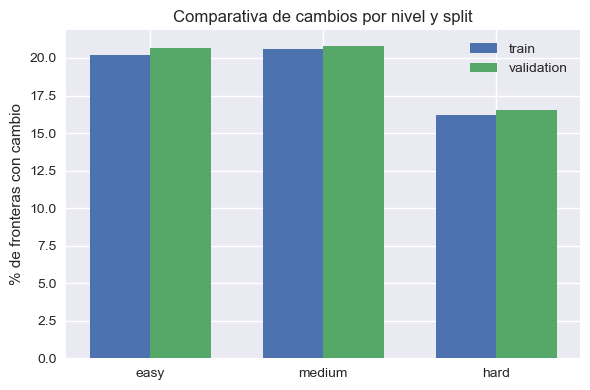

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
bar_width = 0.35
levels = LEVELS
data = pct_changes.pivot(index='level', columns='split', values='pct_change').reindex(levels)
indices = np.arange(len(levels))
for i, split in enumerate(pct_changes['split'].unique()):
    if split not in data.columns:
        continue
    ax.bar(indices + i * bar_width, data[split], width=bar_width, label=split)
ax.set_xticks(indices + bar_width / 2)
ax.set_xticklabels(levels)
ax.set_ylabel('% de fronteras con cambio')
ax.set_title('Comparativa de cambios por nivel y split')
ax.legend()
plt.tight_layout()
plt.show()

### ***5. Métricas de segmentación: Pk y WindowDiff***

Pk penaliza pares de frases que deberían compartir segmento y no lo hacen (o viceversa), mientras que WindowDiff cuenta cuántas veces difiere el número de cambios dentro de una ventana deslizante; ambas métricas miden la calidad global de una segmentación sin depender del número exacto de segmentos.

In [14]:
def boundaries_to_segments(y_boundaries: np.ndarray) -> np.ndarray:
    y_boundaries = np.asarray(y_boundaries, dtype=int)
    n_sentences = len(y_boundaries) + 1
    segments = np.zeros(n_sentences, dtype=int)
    current = 0
    segments[0] = current
    for i, val in enumerate(y_boundaries):
        if val:
            current += 1
        segments[i + 1] = current
    return segments


def pk(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    reference = np.asarray(reference)
    hypothesis = np.asarray(hypothesis)
    if len(reference) != len(hypothesis):
        raise ValueError('reference y hypothesis deben tener la misma longitud')
    if k <= 0:
        raise ValueError('k debe ser positivo')
    if len(reference) <= k:
        return 0.0
    disagreements = 0
    total = 0
    for i in range(len(reference) - k):
        same_ref = reference[i] == reference[i + k]
        same_hyp = hypothesis[i] == hypothesis[i + k]
        disagreements += int(same_ref != same_hyp)
        total += 1
    return disagreements / total if total else 0.0


def windowdiff(reference: np.ndarray, hypothesis: np.ndarray, k: int) -> float:
    reference = np.asarray(reference, dtype=int)
    hypothesis = np.asarray(hypothesis, dtype=int)
    if reference.shape != hypothesis.shape:
        raise ValueError('reference y hypothesis deben tener la misma longitud')
    if k <= 0:
        raise ValueError('k debe ser positivo')
    n_sentences = len(reference) + 1
    if n_sentences <= k:
        return 0.0
    total = n_sentences - k + 1
    errors = 0
    for start in range(total):
        end = start + k - 1
        ref_count = reference[start:end].sum()
        hyp_count = hypothesis[start:end].sum()
        errors += int(ref_count != hyp_count)
    return errors / total if total else 0.0

In [15]:
toy_ref = np.array([0, 1, 0, 0, 1])
toy_hyp_good = np.array([0, 1, 0, 0, 1])
toy_hyp_bad = np.array([0, 0, 1, 0, 0])
toy_segments_ref = boundaries_to_segments(toy_ref)
toy_segments_good = boundaries_to_segments(toy_hyp_good)
toy_segments_bad = boundaries_to_segments(toy_hyp_bad)

k_toy = 2
print('Pk perfecto:', pk(toy_segments_ref, toy_segments_good, k=k_toy))
print('Pk con errores:', pk(toy_segments_ref, toy_segments_bad, k=k_toy))
print('WindowDiff perfecto:', windowdiff(toy_ref, toy_hyp_good, k=k_toy))
print('WindowDiff con errores:', windowdiff(toy_ref, toy_hyp_bad, k=k_toy))

Pk perfecto: 0.0
Pk con errores: 0.75
WindowDiff perfecto: 0.0
WindowDiff con errores: 0.6


### ***6. Baselines triviales de detección de cambio de autor***

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_baseline(boundaries_df: pd.DataFrame, y_pred: np.ndarray) -> dict:
    required_cols = {"level", "doc_id", "boundary_id", "y"}
    missing = required_cols.difference(boundaries_df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en boundaries_df: {missing}")
    df = boundaries_df.sort_values(["level", "doc_id", "boundary_id"]).reset_index(drop=True)
    y_true = df["y"].to_numpy()
    y_pred = np.asarray(y_pred, dtype=int)
    if len(y_pred) != len(y_true):
        raise ValueError("y_pred debe tener la misma longitud que y_true")

    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)

    doc_records = []
    segment_lengths = []
    for (_, _doc_id), group in df.groupby(["level", "doc_id"]):
        idx = group.index.to_numpy()
        y_true_doc = group["y"].to_numpy()
        doc_records.append((idx, y_true_doc))
        seg_true = boundaries_to_segments(y_true_doc)
        _, counts = np.unique(seg_true, return_counts=True)
        segment_lengths.extend(counts.tolist())

    mean_segment_length = float(np.mean(segment_lengths)) if segment_lengths else 1.0
    k = max(1, int(round(mean_segment_length / 2)))

    pk_scores = []
    wd_scores = []
    for idx, y_true_doc in doc_records:
        y_pred_doc = y_pred[idx]
        seg_true = boundaries_to_segments(y_true_doc)
        seg_pred = boundaries_to_segments(y_pred_doc)
        pk_scores.append(pk(seg_true, seg_pred, k=k))
        wd_scores.append(windowdiff(y_true_doc, y_pred_doc, k=k))

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pk": float(np.mean(pk_scores)) if pk_scores else np.nan,
        "windowdiff": float(np.mean(wd_scores)) if wd_scores else np.nan,
        "k_window": k,
        "mean_segment_length": mean_segment_length,
    }


p_change_train = boundaries_train["y"].mean()
print(f"Proporción de cambios en train: {p_change_train:.3f}")

y_pred_never = np.zeros(len(boundaries_val), dtype=int)
metrics_never = evaluate_baseline(boundaries_val, y_pred_never)

rng_baseline = np.random.default_rng(123)
y_pred_random = rng_baseline.binomial(1, p_change_train if p_change_train > 0 else 0, size=len(boundaries_val))
metrics_random = evaluate_baseline(boundaries_val, y_pred_random)

results = {
    "never_change": metrics_never,
    "random_p": metrics_random,
}

metrics_df = pd.DataFrame.from_dict(results, orient="index")
display(metrics_df)
print("k utilizado para Pk/WindowDiff (filas):")
print(metrics_df[["k_window", "mean_segment_length"]])
n_pos_val = int(boundaries_val["y"].sum())
n_total_val = len(boundaries_val)
print(f"Fronteras positivas en validation: {n_pos_val} de {n_total_val} ({n_pos_val / n_total_val:.3%})")

Proporción de cambios en train: 0.191


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,pk,windowdiff,k_window,mean_segment_length
never_change,0.806,0.403,0.500,0.446,0.806,0.400,0.206,2,3.945
random_p,0.693,0.502,0.502,0.502,0.693,0.466,0.315,2,3.945


k utilizado para Pk/WindowDiff (filas):
              k_window  mean_segment_length
never_change         2                3.945
random_p             2                3.945
Fronteras positivas en validation: 6568 de 33858 (19.399%)
